In [ ]:
# ============================================================
# CÉLULA 1 - CONFIGURAÇÃO GERAL DO ESTUDO
# ============================================================
#
# Modelo estudado:
# Fila M/M/1 com Abandono Dependente do Tempo de Espera
#
# M/M/1:
# - Chegadas seguem processo de Poisson
# - Tempos entre chegadas seguem distribuição exponencial com taxa lambda
# - Tempos de serviço seguem distribuição exponencial com taxa mu
# - Existe apenas 1 servidor
#
# Abandono:
# - Cada cliente possui uma tolerância máxima de espera definida por theta
# - Essa tolerância segue distribuição exponencial com taxa theta
# - Se o cliente ainda estiver na fila quando sua tolerância acabar, ele abandona o sistema sem ser atendido
# ============================================================

import random
import math
import statistics
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parâmetros base da simulação
# ------------------------------------------------------------

NUMERO_CLIENTES = 5000      # quantidade total de clientes simulados

LAMBDA_BASE = 0.90          # taxa média de chegada dos clientes
MU_BASE = 1.00              # taxa média de atendimento do servidor
THETA_BASE = 0.20           # taxa média de abandono

SEMENTE_BASE = 42           # semente para reprodutibilidade

# ------------------------------------------------------------
# Valores usados nos experimentos
# ------------------------------------------------------------

LAMBDAS_TESTE = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]

MUS_TESTE = [0.6, 0.8, 1.0, 1.2, 1.5]

THETAS_TESTE = [0.01, 0.05, 0.10, 0.20, 0.50, 1.00]


In [ ]:
# ============================================================
# CÉLULA 2 - FUNÇÕES AUXILIARES
# ============================================================

def media(lista):
    """
    Calcula a média de uma lista.
    Retorna zero se a lista estiver vazia.
    """

    if len(lista) == 0:
        return 0.0

    return sum(lista) / len(lista)


def desvio_padrao(lista):
    """
    Calcula o desvio padrão amostral.
    Retorna zero se a lista tiver menos de dois elementos.
    """

    if len(lista) <= 1:
        return 0.0

    return statistics.stdev(lista)


def percentil(lista, p):
    """
    Calcula um percentil simples.

    Exemplo:
    p = 95 calcula o percentil 95.
    """

    if len(lista) == 0:
        return 0.0

    lista_ordenada = sorted(lista)

    indice = int((p / 100) * (len(lista_ordenada) - 1))

    return lista_ordenada[indice]


def formatar_percentual(valor):
    """
    Converte um valor entre 0 e 1 para percentual.
    """

    return 100 * valor

In [ ]:
# ============================================================
# CÉLULA 3 - GERAÇÃO DAS AMOSTRAS ALEATÓRIAS
# ============================================================
#
# Todas as variáveis aleatórias são geradas antes da simulação.
#
# Isso atende ao requisito do trabalho:
# - definir número de amostras
# - gerar tudo que for aleatório no início
# - permitir repetição dos resultados com a mesma semente
# ============================================================

def gerar_amostras(numero_clientes, lambd, mu, theta, semente):
    """
    Gera as amostras aleatórias da simulação.

    Entradas:
    - numero_clientes: quantidade de clientes simulados
    - lambd: taxa de chegada
    - mu: taxa de serviço
    - theta: taxa de abandono
    - semente: semente aleatória

    Saídas:
    - tempos_chegada: instante absoluto de chegada de cada cliente
    - tempos_servico: tempo de atendimento de cada cliente
    - tolerancias: tempo máximo que cada cliente aceita esperar na fila
    """

    random.seed(semente)

    # --------------------------------------------------------
    # Geração dos tempos absolutos de chegada
    # --------------------------------------------------------
    #
    # Em um processo de Poisson, os tempos entre chegadas são
    # exponenciais com taxa lambda.
    # --------------------------------------------------------

    tempos_chegada = []
    tempo_atual = 0.0

    for _ in range(numero_clientes):
        tempo_entre_chegadas = random.expovariate(lambd)
        tempo_atual += tempo_entre_chegadas
        tempos_chegada.append(tempo_atual)

    # --------------------------------------------------------
    # Geração dos tempos de serviço
    # --------------------------------------------------------
    #
    # No modelo M/M/1, os tempos de serviço são exponenciais
    # com taxa mu.
    # --------------------------------------------------------

    tempos_servico = []

    for _ in range(numero_clientes):
        tempos_servico.append(random.expovariate(mu))

    # --------------------------------------------------------
    # Geração das tolerâncias de espera
    # --------------------------------------------------------
    #
    # A tolerância T é exponencial com taxa theta.
    # Se theta <= 0, consideramos que não existe abandono.
    # --------------------------------------------------------

    tolerancias = []

    for _ in range(numero_clientes):
        if theta > 0:
            tolerancias.append(random.expovariate(theta))
        else:
            tolerancias.append(math.inf)

    return tempos_chegada, tempos_servico, tolerancias

In [ ]:
# ============================================================
# CÉLULA 3 - GERAÇÃO DAS AMOSTRAS ALEATÓRIAS
# ============================================================
#
# Todas as variáveis aleatórias são geradas antes da simulação.
#
# Isso atende ao requisito do trabalho:
# - definir número de amostras
# - gerar tudo que for aleatório no início
# - permitir repetição dos resultados com a mesma semente
# ============================================================

def gerar_amostras(numero_clientes, lambd, mu, theta, semente):
    """
    Gera as amostras aleatórias da simulação.

    Entradas:
    - numero_clientes: quantidade de clientes simulados
    - lambd: taxa de chegada
    - mu: taxa de serviço
    - theta: taxa de abandono
    - semente: semente aleatória

    Saídas:
    - tempos_chegada: instante absoluto de chegada de cada cliente
    - tempos_servico: tempo de atendimento de cada cliente
    - tolerancias: tempo máximo que cada cliente aceita esperar na fila
    """

    random.seed(semente)

    # --------------------------------------------------------
    # Geração dos tempos absolutos de chegada
    # --------------------------------------------------------
    #
    # Em um processo de Poisson, os tempos entre chegadas são
    # exponenciais com taxa lambda.
    # --------------------------------------------------------

    tempos_chegada = []
    tempo_atual = 0.0

    for _ in range(numero_clientes):
        tempo_entre_chegadas = random.expovariate(lambd)
        tempo_atual += tempo_entre_chegadas
        tempos_chegada.append(tempo_atual)

    # --------------------------------------------------------
    # Geração dos tempos de serviço
    # --------------------------------------------------------
    #
    # No modelo M/M/1, os tempos de serviço são exponenciais
    # com taxa mu.
    # --------------------------------------------------------

    tempos_servico = []

    for _ in range(numero_clientes):
        tempos_servico.append(random.expovariate(mu))

    # --------------------------------------------------------
    # Geração das tolerâncias de espera
    # --------------------------------------------------------
    #
    # A tolerância T é exponencial com taxa theta.
    # Se theta <= 0, consideramos que não existe abandono.
    # --------------------------------------------------------

    tolerancias = []

    for _ in range(numero_clientes):
        if theta > 0:
            tolerancias.append(random.expovariate(theta))
        else:
            tolerancias.append(math.inf)

    return tempos_chegada, tempos_servico, tolerancias

In [ ]:
# ============================================================
# CÉLULA 4 - SIMULADOR M/M/1 COM ABANDONO
# ============================================================
#
# Esta versão usa simulação por eventos discretos.
#
# Eventos:
# 1. Chegada de cliente
# 2. Saída por término de atendimento
# 3. Abandono de cliente em fila
#
# O cliente só abandona enquanto está esperando na fila.
# Depois que começa atendimento, ele não abandona mais.
# ============================================================

def simular_mm1_abandono(numero_clientes, lambd, mu, theta, semente=42):
    """
    Simula uma fila M/M/1 com abandono.

    Retorna:
    - métricas finais
    - histórico temporal para gráficos
    - listas de tempos individuais
    """

    # --------------------------------------------------------
    # Geração das amostras
    # --------------------------------------------------------

    tempos_chegada, tempos_servico, tolerancias = gerar_amostras(
        numero_clientes,
        lambd,
        mu,
        theta,
        semente
    )

    # --------------------------------------------------------
    # Criação da lista de clientes
    # --------------------------------------------------------

    clientes = []

    for i in range(numero_clientes):
        cliente = {
            "id": i,
            "chegada": tempos_chegada[i],
            "servico": tempos_servico[i],
            "tolerancia": tolerancias[i],
            "limite_abandono": tempos_chegada[i] + tolerancias[i],
            "inicio_servico": None,
            "saida": None,
            "abandono": None,
            "status": "nao_chegou"
        }

        clientes.append(cliente)

    # --------------------------------------------------------
    # Estado inicial da simulação
    # --------------------------------------------------------

    tempo_atual = 0.0

    indice_proxima_chegada = 0

    fila = []

    servidor_ocupado = False
    cliente_em_atendimento = None
    proxima_saida = math.inf

    # --------------------------------------------------------
    # Contadores
    # --------------------------------------------------------

    total_chegadas = 0
    total_atendidos = 0
    total_abandonos = 0

    # --------------------------------------------------------
    # Listas para cálculo de tempos
    # --------------------------------------------------------

    tempos_espera_atendidos = []
    tempos_sistema_atendidos = []
    tempos_espera_abandonados = []

    # --------------------------------------------------------
    # Áreas para cálculo de médias temporais
    # --------------------------------------------------------
    #
    # Lq = número médio na fila
    # L = número médio no sistema
    # Utilização = fração do tempo em que o servidor esteve ocupado
    # --------------------------------------------------------

    ultimo_tempo_evento = 0.0

    area_fila = 0.0
    area_sistema = 0.0
    area_servidor_ocupado = 0.0

    # --------------------------------------------------------
    # Histórico para gráficos
    # --------------------------------------------------------

    historico_tempo = []
    historico_fila = []
    historico_sistema = []
    historico_atendidos = []
    historico_abandonos = []
    historico_utilizacao = []

    # ========================================================
    # LOOP PRINCIPAL
    # ========================================================

    while total_atendidos + total_abandonos < numero_clientes:

        # ----------------------------------------------------
        # Próxima chegada
        # ----------------------------------------------------

        if indice_proxima_chegada < numero_clientes:
            proxima_chegada = clientes[indice_proxima_chegada]["chegada"]
        else:
            proxima_chegada = math.inf

        # ----------------------------------------------------
        # Próximo abandono
        # ----------------------------------------------------
        #
        # O próximo abandono é o menor limite de abandono
        # entre os clientes que estão esperando na fila.
        # ----------------------------------------------------

        proximo_abandono = math.inf
        cliente_abandono = None

        for id_cliente in fila:
            limite = clientes[id_cliente]["limite_abandono"]

            if limite < proximo_abandono:
                proximo_abandono = limite
                cliente_abandono = id_cliente

        # ----------------------------------------------------
        # Escolha do próximo evento
        # ----------------------------------------------------

        tempo_proximo_evento = min(
            proxima_chegada,
            proxima_saida,
            proximo_abandono
        )

        if tempo_proximo_evento == math.inf:
            break

        # ----------------------------------------------------
        # Atualização das áreas temporais
        # ----------------------------------------------------

        intervalo = tempo_proximo_evento - ultimo_tempo_evento

        tamanho_fila = len(fila)

        clientes_no_sistema = tamanho_fila

        if servidor_ocupado:
            clientes_no_sistema += 1
            area_servidor_ocupado += intervalo

        area_fila += tamanho_fila * intervalo
        area_sistema += clientes_no_sistema * intervalo

        tempo_atual = tempo_proximo_evento
        ultimo_tempo_evento = tempo_atual

        # ----------------------------------------------------
        # Prioridade em caso de empate:
        # 1. Saída
        # 2. Chegada
        # 3. Abandono
        #
        # Essa escolha evita contar abandono quando o cliente
        # começa atendimento exatamente no limite.
        # ----------------------------------------------------

        if abs(tempo_atual - proxima_saida) < 1e-12:

            # =================================================
            # EVENTO 1: SAÍDA
            # =================================================

            cliente = clientes[cliente_em_atendimento]

            cliente["saida"] = tempo_atual
            cliente["status"] = "atendido"

            total_atendidos += 1

            espera = cliente["inicio_servico"] - cliente["chegada"]
            tempo_sistema = cliente["saida"] - cliente["chegada"]

            tempos_espera_atendidos.append(espera)
            tempos_sistema_atendidos.append(tempo_sistema)

            cliente_em_atendimento = None

            # -----------------------------------------------
            # Após uma saída, se houver fila,
            # o próximo cliente válido inicia atendimento.
            # -----------------------------------------------

            while len(fila) > 0:

                proximo_id = fila.pop(0)
                proximo_cliente = clientes[proximo_id]

                # Se a tolerância já foi ultrapassada,
                # o cliente abandona antes de ser atendido.
                if tempo_atual > proximo_cliente["limite_abandono"]:

                    proximo_cliente["abandono"] = proximo_cliente["limite_abandono"]
                    proximo_cliente["status"] = "abandonou"

                    total_abandonos += 1

                    tempos_espera_abandonados.append(
                        proximo_cliente["limite_abandono"] - proximo_cliente["chegada"]
                    )

                    continue

                # Cliente inicia atendimento.
                proximo_cliente["inicio_servico"] = tempo_atual
                proximo_cliente["status"] = "em_atendimento"

                cliente_em_atendimento = proximo_id
                servidor_ocupado = True
                proxima_saida = tempo_atual + proximo_cliente["servico"]

                break

            else:
                # Se a fila ficou vazia, o servidor fica livre.
                servidor_ocupado = False
                proxima_saida = math.inf

        elif abs(tempo_atual - proxima_chegada) < 1e-12:

            # =================================================
            # EVENTO 2: CHEGADA
            # =================================================

            cliente = clientes[indice_proxima_chegada]

            cliente["status"] = "chegou"
            total_chegadas += 1

            # Se o servidor está livre, inicia atendimento.
            if not servidor_ocupado:

                cliente["inicio_servico"] = tempo_atual
                cliente["status"] = "em_atendimento"

                cliente_em_atendimento = cliente["id"]
                servidor_ocupado = True

                proxima_saida = tempo_atual + cliente["servico"]

            else:
                # Caso contrário, entra na fila.
                cliente["status"] = "em_fila"
                fila.append(cliente["id"])

            indice_proxima_chegada += 1

        else:

            # =================================================
            # EVENTO 3: ABANDONO
            # =================================================

            if cliente_abandono in fila:

                fila.remove(cliente_abandono)

                cliente = clientes[cliente_abandono]

                cliente["abandono"] = tempo_atual
                cliente["status"] = "abandonou"

                total_abandonos += 1

                tempos_espera_abandonados.append(
                    cliente["abandono"] - cliente["chegada"]
                )

        # ----------------------------------------------------
        # Registro do histórico após o evento
        # ----------------------------------------------------

        clientes_no_sistema = len(fila) + (1 if servidor_ocupado else 0)

        historico_tempo.append(tempo_atual)
        historico_fila.append(len(fila))
        historico_sistema.append(clientes_no_sistema)
        historico_atendidos.append(total_atendidos)
        historico_abandonos.append(total_abandonos)

        if tempo_atual > 0:
            historico_utilizacao.append(area_servidor_ocupado / tempo_atual)
        else:
            historico_utilizacao.append(0.0)

    # ========================================================
    # CÁLCULO DAS MÉTRICAS FINAIS
    # ========================================================

    tempo_total = max(ultimo_tempo_evento, 1e-9)

    taxa_atendimento = total_atendidos / numero_clientes
    taxa_abandono = total_abandonos / numero_clientes

    throughput = total_atendidos / tempo_total

    utilizacao_servidor = area_servidor_ocupado / tempo_total

    numero_medio_fila = area_fila / tempo_total
    numero_medio_sistema = area_sistema / tempo_total

    resultados = {
        "Número de clientes": numero_clientes,
        "λ": lambd,
        "μ": mu,
        "θ": theta,
        "ρ teórico λ/μ": lambd / mu,
        "Tempo total simulado": tempo_total,

        "Clientes atendidos": total_atendidos,
        "Clientes abandonaram": total_abandonos,

        "Taxa de atendimento": taxa_atendimento,
        "Taxa de abandono": taxa_abandono,

        "Throughput": throughput,
        "Utilização do servidor": utilizacao_servidor,

        "Número médio na fila Lq": numero_medio_fila,
        "Número médio no sistema L": numero_medio_sistema,

        "Tempo médio de espera dos atendidos": media(tempos_espera_atendidos),
        "Tempo médio no sistema dos atendidos": media(tempos_sistema_atendidos),

        "Tempo médio até abandono": media(tempos_espera_abandonados),

        "Espera máxima dos atendidos": max(tempos_espera_atendidos) if len(tempos_espera_atendidos) > 0 else 0.0,
        "Desvio padrão da espera": desvio_padrao(tempos_espera_atendidos),
        "Percentil 95 da espera": percentil(tempos_espera_atendidos, 95),
    }

    historico = {
        "tempo": historico_tempo,
        "fila": historico_fila,
        "sistema": historico_sistema,
        "atendidos": historico_atendidos,
        "abandonos": historico_abandonos,
        "utilizacao": historico_utilizacao
    }

    tempos = {
        "espera_atendidos": tempos_espera_atendidos,
        "sistema_atendidos": tempos_sistema_atendidos,
        "espera_abandonados": tempos_espera_abandonados
    }

    return resultados, historico, tempos

In [ ]:
# ============================================================
# CÉLULA 5 - EXECUÇÃO BASE
# ============================================================

resultados_base, historico_base, tempos_base = simular_mm1_abandono(
    numero_clientes=NUMERO_CLIENTES,
    lambd=LAMBDA_BASE,
    mu=MU_BASE,
    theta=THETA_BASE,
    semente=SEMENTE_BASE
)

# ------------------------------------------------------------
# Tabela com as métricas principais
# ------------------------------------------------------------

df_resultados_base = pd.DataFrame(
    resultados_base.items(),
    columns=["Métrica", "Valor"]
)

display(df_resultados_base)

,Métrica,Valor
0,Número de clientes,5000.000000
1,λ,0.900000
2,μ,1.000000
3,θ,0.200000
4,ρ teórico λ/μ,0.900000
5,Tempo total simulado,5563.053771
6,Clientes atendidos,3945.000000
7,Clientes abandonaram,1055.000000
8,Taxa de atendimento,0.789000
9,Taxa de abandono,0.211000


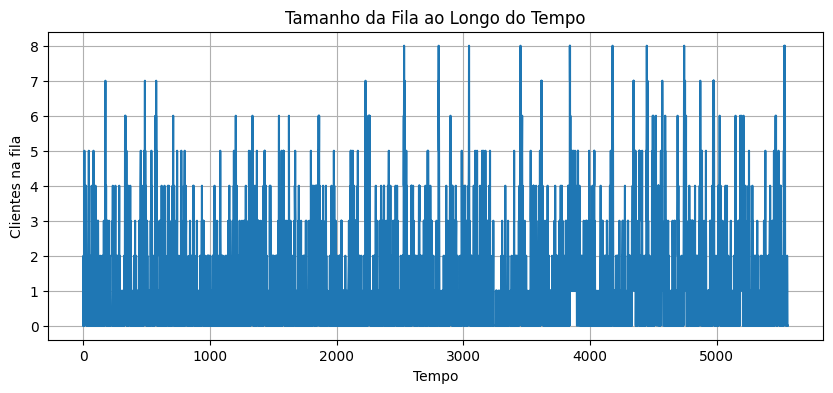

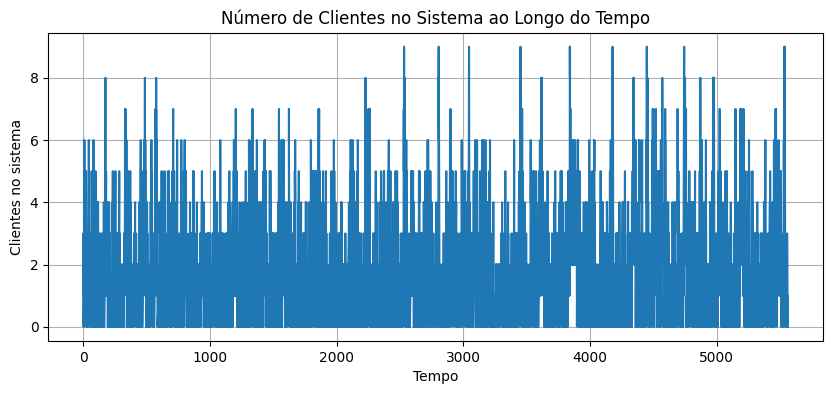

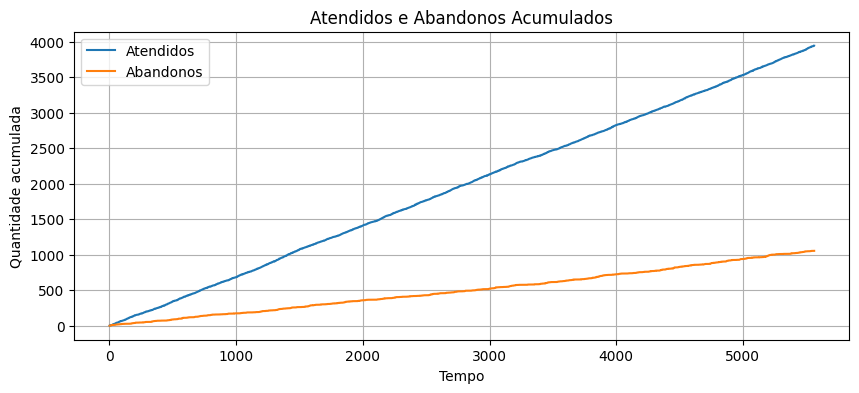

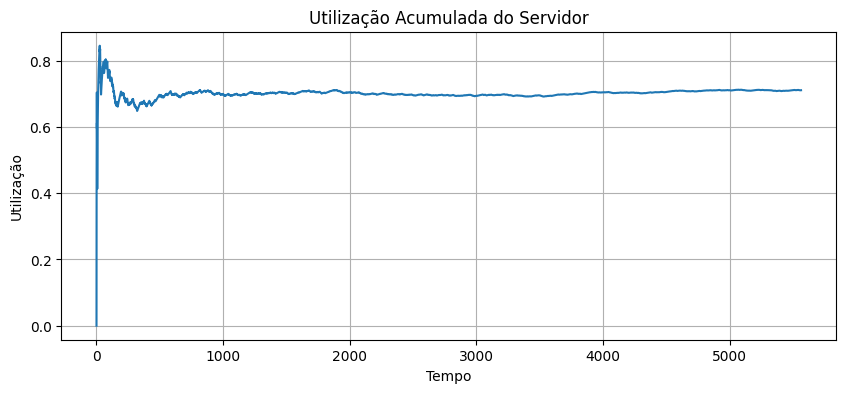

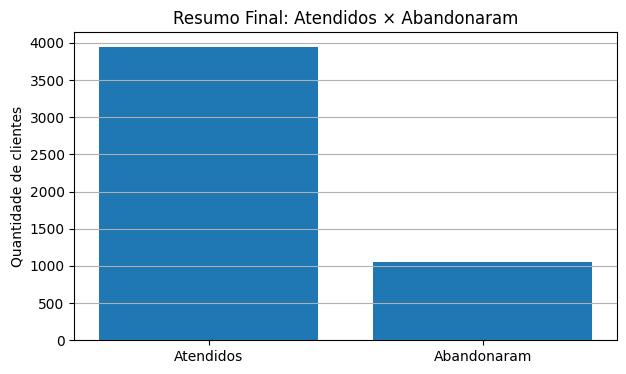

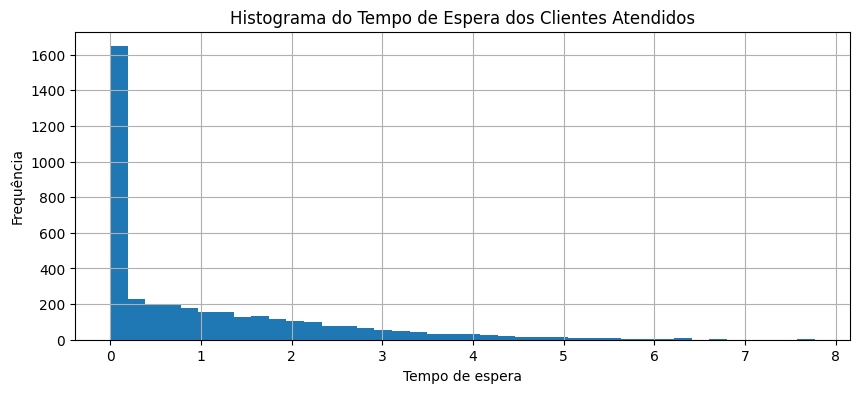

In [ ]:
# ============================================================
# CÉLULA 6 - GRÁFICOS TEMPORAIS DA EXECUÇÃO BASE
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(historico_base["tempo"], historico_base["fila"])
plt.title("Tamanho da Fila ao Longo do Tempo")
plt.xlabel("Tempo")
plt.ylabel("Clientes na fila")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico_base["tempo"], historico_base["sistema"])
plt.title("Número de Clientes no Sistema ao Longo do Tempo")
plt.xlabel("Tempo")
plt.ylabel("Clientes no sistema")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico_base["tempo"], historico_base["atendidos"], label="Atendidos")
plt.plot(historico_base["tempo"], historico_base["abandonos"], label="Abandonos")
plt.title("Atendidos e Abandonos Acumulados")
plt.xlabel("Tempo")
plt.ylabel("Quantidade acumulada")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico_base["tempo"], historico_base["utilizacao"])
plt.title("Utilização Acumulada do Servidor")
plt.xlabel("Tempo")
plt.ylabel("Utilização")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(
    ["Atendidos", "Abandonaram"],
    [
        resultados_base["Clientes atendidos"],
        resultados_base["Clientes abandonaram"]
    ]
)
plt.title("Resumo Final: Atendidos × Abandonaram")
plt.ylabel("Quantidade de clientes")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(tempos_base["espera_atendidos"], bins=40)
plt.title("Histograma do Tempo de Espera dos Clientes Atendidos")
plt.xlabel("Tempo de espera")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# CÉLULA 7 - EXPERIMENTO 1
# IMPACTO DA TAXA DE CHEGADA λ
# ============================================================
#
# Neste experimento:
# - μ é mantido fixo
# - θ é mantido fixo
# - λ varia
#
# Objetivo:
# Verificar como o aumento da demanda afeta:
# - tempo de espera
# - abandono
# - throughput
# - tamanho médio da fila
# ============================================================

dados_lambda = []

for lambd in LAMBDAS_TESTE:

    r, h, t = simular_mm1_abandono(
        numero_clientes=NUMERO_CLIENTES,
        lambd=lambd,
        mu=MU_BASE,
        theta=THETA_BASE,
        semente=SEMENTE_BASE
    )

    dados_lambda.append({
        "λ": lambd,
        "ρ = λ/μ": r["ρ teórico λ/μ"],
        "Atendidos": r["Clientes atendidos"],
        "Abandonaram": r["Clientes abandonaram"],
        "Taxa de abandono (%)": formatar_percentual(r["Taxa de abandono"]),
        "Tempo médio de espera": r["Tempo médio de espera dos atendidos"],
        "Lq": r["Número médio na fila Lq"],
        "L": r["Número médio no sistema L"],
        "Utilização (%)": formatar_percentual(r["Utilização do servidor"]),
        "Throughput": r["Throughput"]
    })

df_lambda = pd.DataFrame(dados_lambda)

display(df_lambda)

,λ,ρ = λ/μ,Atendidos,Abandonaram,Taxa de abandono (%),Tempo médio de espera,Lq,L,Utilização (%),Throughput
0,0.2,0.2,4827,173,3.46,0.147714,0.034222,0.226542,19.231971,0.192822
1,0.4,0.4,4623,377,7.54,0.325604,0.149937,0.518457,36.851969,0.369344
2,0.6,0.6,4380,620,12.40,0.548834,0.367738,0.890267,52.252908,0.524894
3,0.8,0.8,4102,898,17.96,0.847860,0.728300,1.386687,65.838743,0.655436
4,1.0,1.0,3796,1204,24.08,1.158349,1.197369,1.954474,75.710484,0.758173
5,1.2,1.2,3503,1497,29.94,1.517696,1.809006,2.648314,83.930751,0.839361


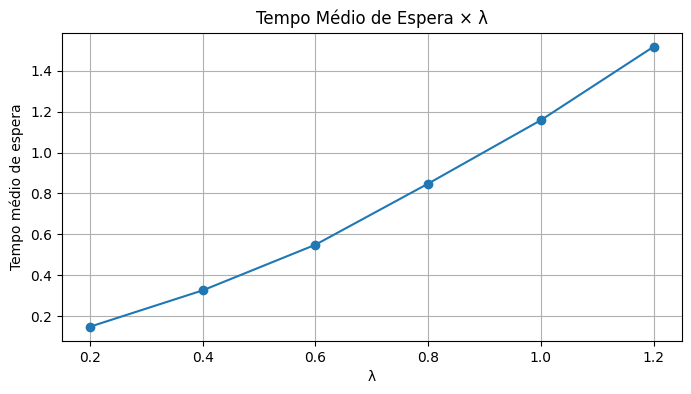

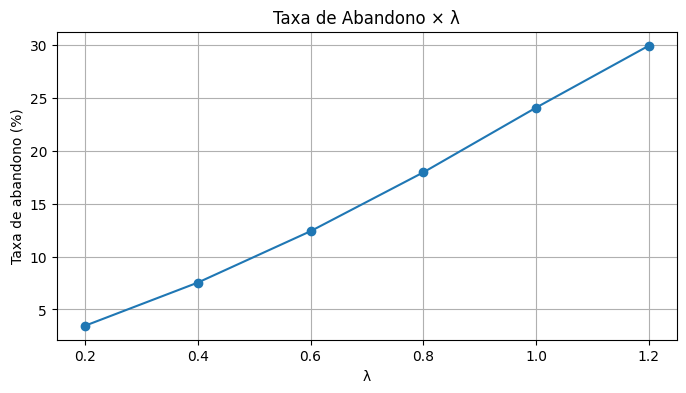

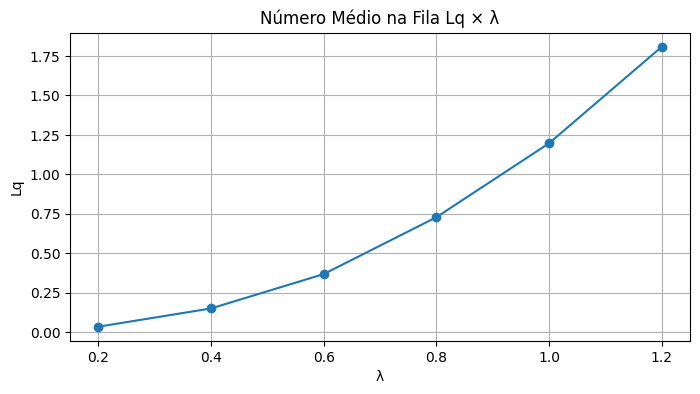

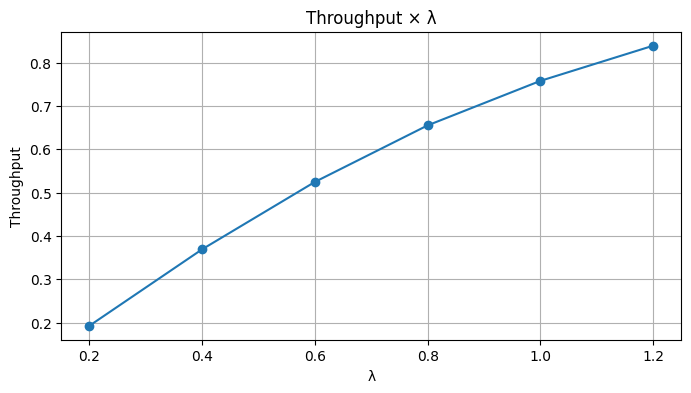

In [ ]:
# ============================================================
# CÉLULA 8 - GRÁFICOS DO IMPACTO DE λ
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(df_lambda["λ"], df_lambda["Tempo médio de espera"], marker="o")
plt.title("Tempo Médio de Espera × λ")
plt.xlabel("λ")
plt.ylabel("Tempo médio de espera")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_lambda["λ"], df_lambda["Taxa de abandono (%)"], marker="o")
plt.title("Taxa de Abandono × λ")
plt.xlabel("λ")
plt.ylabel("Taxa de abandono (%)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_lambda["λ"], df_lambda["Lq"], marker="o")
plt.title("Número Médio na Fila Lq × λ")
plt.xlabel("λ")
plt.ylabel("Lq")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_lambda["λ"], df_lambda["Throughput"], marker="o")
plt.title("Throughput × λ")
plt.xlabel("λ")
plt.ylabel("Throughput")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# CÉLULA 9 - EXPERIMENTO 2
# IMPACTO DA TAXA DE ABANDONO θ
# ============================================================
#
# Neste experimento:
# - λ é mantido fixo
# - μ é mantido fixo
# - θ varia
#
# Objetivo:
# Verificar como a paciência dos clientes afeta:
# - taxa de abandono
# - tempo médio de espera
# - throughput
# - tamanho médio da fila
# ============================================================

dados_theta = []

for theta in THETAS_TESTE:

    r, h, t = simular_mm1_abandono(
        numero_clientes=NUMERO_CLIENTES,
        lambd=LAMBDA_BASE,
        mu=MU_BASE,
        theta=theta,
        semente=SEMENTE_BASE
    )

    dados_theta.append({
        "θ": theta,
        "Tolerância média 1/θ": 1 / theta if theta > 0 else math.inf,
        "Atendidos": r["Clientes atendidos"],
        "Abandonaram": r["Clientes abandonaram"],
        "Taxa de abandono (%)": formatar_percentual(r["Taxa de abandono"]),
        "Tempo médio de espera": r["Tempo médio de espera dos atendidos"],
        "Tempo médio até abandono": r["Tempo médio até abandono"],
        "Lq": r["Número médio na fila Lq"],
        "Utilização (%)": formatar_percentual(r["Utilização do servidor"]),
        "Throughput": r["Throughput"]
    })

df_theta = pd.DataFrame(dados_theta)

display(df_theta)

,θ,Tolerância média 1/θ,Atendidos,Abandonaram,Taxa de abandono (%),Tempo médio de espera,Tempo médio até abandono,Lq,Utilização (%),Throughput
0,0.01,100.0,4780,220,4.40,4.689882,4.543017,4.209397,85.795430,0.859240
1,0.05,20.0,4409,591,11.82,2.381055,2.681607,2.171991,79.573823,0.792550
2,0.10,10.0,4203,797,15.94,1.580337,1.781738,1.449241,75.517084,0.755520
3,0.20,5.0,3945,1055,21.10,1.014279,1.256848,0.957623,71.084657,0.709143
4,0.50,2.0,3580,1420,28.40,0.479065,0.803795,0.513467,64.141298,0.643531
5,1.00,1.0,3281,1719,34.38,0.229910,0.547075,0.304645,59.257841,0.589784


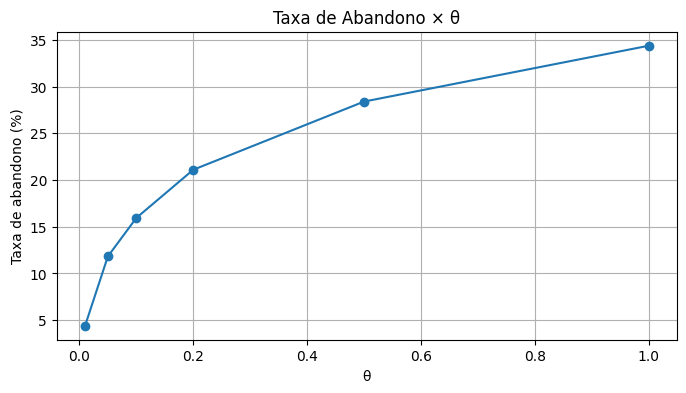

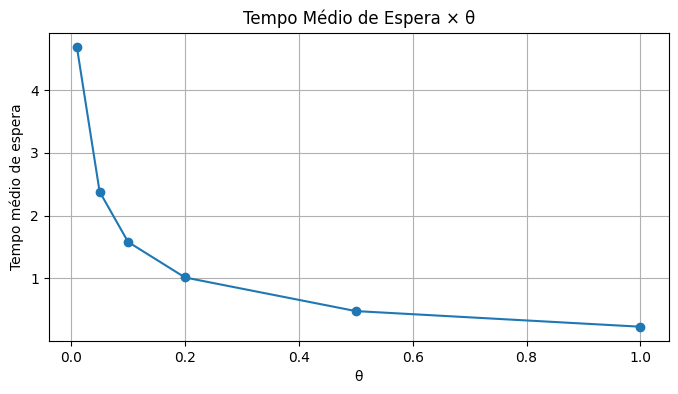

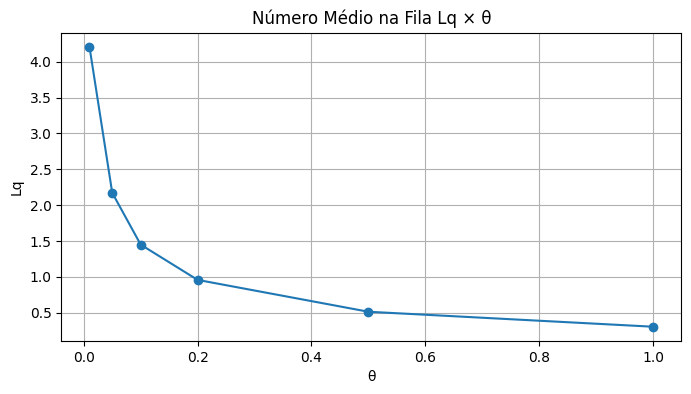

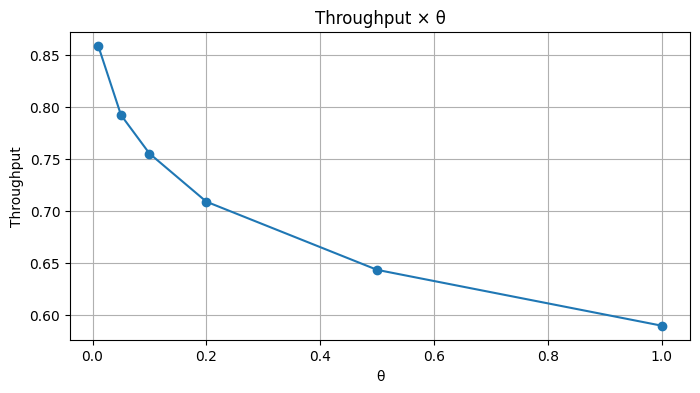

In [ ]:
# ============================================================
# CÉLULA 10 - GRÁFICOS DO IMPACTO DE θ
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(df_theta["θ"], df_theta["Taxa de abandono (%)"], marker="o")
plt.title("Taxa de Abandono × θ")
plt.xlabel("θ")
plt.ylabel("Taxa de abandono (%)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_theta["θ"], df_theta["Tempo médio de espera"], marker="o")
plt.title("Tempo Médio de Espera × θ")
plt.xlabel("θ")
plt.ylabel("Tempo médio de espera")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_theta["θ"], df_theta["Lq"], marker="o")
plt.title("Número Médio na Fila Lq × θ")
plt.xlabel("θ")
plt.ylabel("Lq")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_theta["θ"], df_theta["Throughput"], marker="o")
plt.title("Throughput × θ")
plt.xlabel("θ")
plt.ylabel("Throughput")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# CÉLULA 11 - EXPERIMENTO 3
# IMPACTO DA TAXA DE SERVIÇO μ
# ============================================================
#
# Neste experimento:
# - λ é mantido fixo
# - θ é mantido fixo
# - μ varia
#
# Objetivo:
# Verificar como a velocidade do servidor afeta:
# - tempo de espera
# - abandono
# - utilização
# - throughput
# ============================================================

dados_mu = []

for mu in MUS_TESTE:

    r, h, t = simular_mm1_abandono(
        numero_clientes=NUMERO_CLIENTES,
        lambd=LAMBDA_BASE,
        mu=mu,
        theta=THETA_BASE,
        semente=SEMENTE_BASE
    )

    dados_mu.append({
        "μ": mu,
        "ρ = λ/μ": LAMBDA_BASE / mu,
        "Atendidos": r["Clientes atendidos"],
        "Abandonaram": r["Clientes abandonaram"],
        "Taxa de abandono (%)": formatar_percentual(r["Taxa de abandono"]),
        "Tempo médio de espera": r["Tempo médio de espera dos atendidos"],
        "Lq": r["Número médio na fila Lq"],
        "Utilização (%)": formatar_percentual(r["Utilização do servidor"]),
        "Throughput": r["Throughput"]
    })

df_mu = pd.DataFrame(dados_mu)

display(df_mu)

,μ,ρ = λ/μ,Atendidos,Abandonaram,Taxa de abandono (%),Tempo médio de espera,Lq,Utilização (%),Throughput
0,0.6,1.500,2974,2026,40.52,2.059846,1.817082,87.343796,0.534537
1,0.8,1.125,3540,1460,29.20,1.466813,1.339613,79.260490,0.636246
2,1.0,0.900,3945,1055,21.10,1.014279,0.957623,71.084657,0.709143
3,1.2,0.750,4248,752,15.04,0.701029,0.676421,63.574150,0.763611
4,1.5,0.600,4492,508,10.16,0.450568,0.440332,53.666963,0.807474


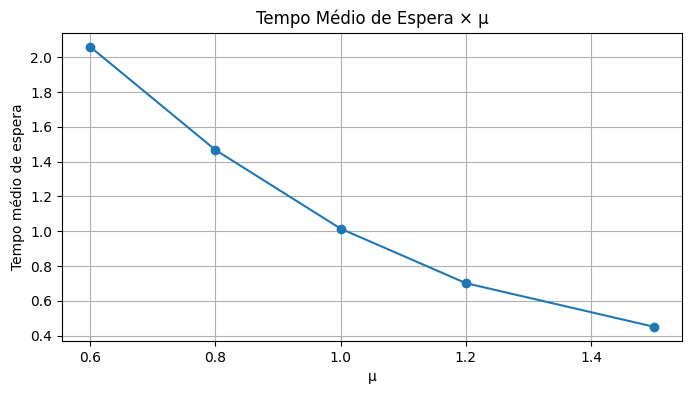

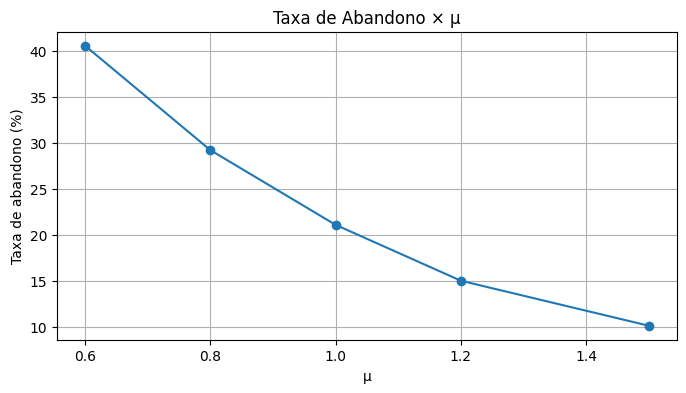

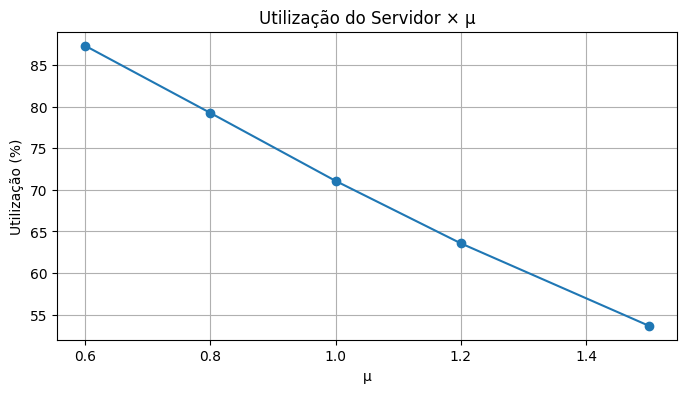

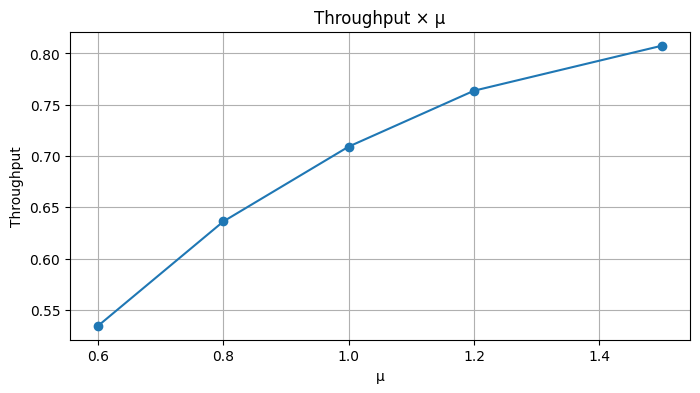

In [ ]:
# ============================================================
# CÉLULA 12 - GRÁFICOS DO IMPACTO DE μ
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(df_mu["μ"], df_mu["Tempo médio de espera"], marker="o")
plt.title("Tempo Médio de Espera × μ")
plt.xlabel("μ")
plt.ylabel("Tempo médio de espera")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_mu["μ"], df_mu["Taxa de abandono (%)"], marker="o")
plt.title("Taxa de Abandono × μ")
plt.xlabel("μ")
plt.ylabel("Taxa de abandono (%)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_mu["μ"], df_mu["Utilização (%)"], marker="o")
plt.title("Utilização do Servidor × μ")
plt.xlabel("μ")
plt.ylabel("Utilização (%)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_mu["μ"], df_mu["Throughput"], marker="o")
plt.title("Throughput × μ")
plt.xlabel("μ")
plt.ylabel("Throughput")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# CÉLULA 13 - TABELA FINAL CENÁRIO MM1 COM ABANDONO
# ============================================================

tabela_relatorio = pd.DataFrame([
    {
        "Cenário": "Base",
        "λ": LAMBDA_BASE,
        "μ": MU_BASE,
        "θ": THETA_BASE,
        "Atendidos": resultados_base["Clientes atendidos"],
        "Abandonaram": resultados_base["Clientes abandonaram"],
        "Taxa abandono (%)": formatar_percentual(resultados_base["Taxa de abandono"]),
        "Espera média": resultados_base["Tempo médio de espera dos atendidos"],
        "Lq": resultados_base["Número médio na fila Lq"],
        "L": resultados_base["Número médio no sistema L"],
        "Utilização (%)": formatar_percentual(resultados_base["Utilização do servidor"]),
        "Throughput": resultados_base["Throughput"]
    }
])

display(tabela_relatorio)

,Cenário,λ,μ,θ,Atendidos,Abandonaram,Taxa abandono (%),Espera média,Lq,L,Utilização (%),Throughput
0,Base,0.9,1.0,0.2,3945,1055,21.1,1.014279,0.957623,1.668469,71.084657,0.709143


In [ ]:
# ============================================================
# CÉLULA 14 - SIMULADOR PARA COMPARAÇÃO
# ============================================================
#
# Esta célula compara:
# M/M/1 com abandono
#
# com três modelos clássicos:
#
# 1. M/M/1 sem abandono
# 2. M/D/1 sem abandono
# 3. M/M/2 sem abandono
#
# A simulação usa a mesma lógica de eventos discretos:
# - chegada
# - saída
# - abandono, quando ativo
# ============================================================

def simular_fila_comparativa(
    nome_modelo,
    numero_clientes,
    lambd,
    mu,
    theta,
    numero_servidores=1,
    servico_deterministico=False,
    abandono_ativo=True,
    semente=42
):
    """
    Simula uma fila genérica para comparação.

    Parâmetros:
    - nome_modelo: nome do modelo simulado.
    - numero_clientes: número total de clientes.
    - lambd: taxa de chegada λ.
    - mu: taxa de serviço μ.
    - theta: taxa de abandono θ.
    - numero_servidores: quantidade de servidores.
    - servico_deterministico: True para M/D/1.
    - abandono_ativo: True para permitir abandono.
    - semente: semente aleatória.
    """

    # --------------------------------------------------------
    # Gera todas as amostras aleatórias no início.
    # --------------------------------------------------------

    tempos_chegada, tempos_servico, tolerancias = gerar_amostras(
        numero_clientes,
        lambd,
        mu,
        theta,
        semente
    )

    # --------------------------------------------------------
    # No modelo M/D/1, o serviço é determinístico.
    # Logo, todo cliente possui tempo de serviço igual a 1/μ.
    # --------------------------------------------------------

    if servico_deterministico:
        tempos_servico = [1 / mu for _ in range(numero_clientes)]

    # --------------------------------------------------------
    # Se não houver abandono, a tolerância é infinita.
    # --------------------------------------------------------

    if not abandono_ativo:
        tolerancias = [math.inf for _ in range(numero_clientes)]

    # --------------------------------------------------------
    # Criação dos clientes.
    # --------------------------------------------------------

    clientes = []

    for i in range(numero_clientes):
        clientes.append({
            "id": i,
            "chegada": tempos_chegada[i],
            "servico": tempos_servico[i],
            "limite_abandono": tempos_chegada[i] + tolerancias[i],
            "inicio_servico": None,
            "saida": None,
            "abandono": None,
            "status": "nao_chegou"
        })

    # --------------------------------------------------------
    # Estado inicial do sistema.
    # --------------------------------------------------------

    fila = []

    indice_proxima_chegada = 0

    # Cada servidor pode estar livre ou ocupado.
    servidores = [None for _ in range(numero_servidores)]

    # Tempo da próxima saída de cada servidor.
    proximas_saidas = [math.inf for _ in range(numero_servidores)]

    total_atendidos = 0
    total_abandonos = 0

    tempos_espera_atendidos = []
    tempos_sistema_atendidos = []
    tempos_espera_abandonados = []

    ultimo_tempo_evento = 0.0

    area_fila = 0.0
    area_sistema = 0.0
    area_ocupacao_total = 0.0

    # ========================================================
    # LOOP PRINCIPAL DE EVENTOS
    # ========================================================

    while total_atendidos + total_abandonos < numero_clientes:

        # ----------------------------------------------------
        # Próxima chegada.
        # ----------------------------------------------------

        if indice_proxima_chegada < numero_clientes:
            proxima_chegada = clientes[indice_proxima_chegada]["chegada"]
        else:
            proxima_chegada = math.inf

        # ----------------------------------------------------
        # Próxima saída entre todos os servidores.
        # ----------------------------------------------------

        proxima_saida = min(proximas_saidas)
        servidor_saida = proximas_saidas.index(proxima_saida)

        # ----------------------------------------------------
        # Próximo abandono.
        # ----------------------------------------------------

        proximo_abandono = math.inf
        cliente_abandono = None

        for id_cliente in fila:
            limite = clientes[id_cliente]["limite_abandono"]

            if limite < proximo_abandono:
                proximo_abandono = limite
                cliente_abandono = id_cliente

        # ----------------------------------------------------
        # Próximo evento.
        # ----------------------------------------------------

        tempo_proximo_evento = min(
            proxima_chegada,
            proxima_saida,
            proximo_abandono
        )

        if tempo_proximo_evento == math.inf:
            break

        # ----------------------------------------------------
        # Atualização das áreas para cálculo de L, Lq e uso.
        # ----------------------------------------------------

        intervalo = tempo_proximo_evento - ultimo_tempo_evento

        servidores_ocupados = sum(1 for s in servidores if s is not None)

        area_fila += len(fila) * intervalo

        area_sistema += (len(fila) + servidores_ocupados) * intervalo

        area_ocupacao_total += servidores_ocupados * intervalo

        tempo_atual = tempo_proximo_evento

        ultimo_tempo_evento = tempo_atual

        # ====================================================
        # EVENTO 1 - SAÍDA
        # ====================================================

        if abs(tempo_atual - proxima_saida) < 1e-12:

            id_cliente = servidores[servidor_saida]

            cliente = clientes[id_cliente]

            cliente["saida"] = tempo_atual
            cliente["status"] = "atendido"

            total_atendidos += 1

            espera = cliente["inicio_servico"] - cliente["chegada"]

            tempo_sistema = cliente["saida"] - cliente["chegada"]

            tempos_espera_atendidos.append(espera)
            tempos_sistema_atendidos.append(tempo_sistema)

            servidores[servidor_saida] = None
            proximas_saidas[servidor_saida] = math.inf

            # ------------------------------------------------
            # Após a saída, se houver fila, coloca o próximo
            # cliente válido nesse servidor.
            # ------------------------------------------------

            while len(fila) > 0:

                proximo_id = fila.pop(0)
                proximo_cliente = clientes[proximo_id]

                if abandono_ativo and tempo_atual > proximo_cliente["limite_abandono"]:

                    proximo_cliente["abandono"] = proximo_cliente["limite_abandono"]
                    proximo_cliente["status"] = "abandonou"

                    total_abandonos += 1

                    tempos_espera_abandonados.append(
                        proximo_cliente["limite_abandono"] - proximo_cliente["chegada"]
                    )

                    continue

                proximo_cliente["inicio_servico"] = tempo_atual
                proximo_cliente["status"] = "em_atendimento"

                servidores[servidor_saida] = proximo_id
                proximas_saidas[servidor_saida] = tempo_atual + proximo_cliente["servico"]

                break

        # ====================================================
        # EVENTO 2 - CHEGADA
        # ====================================================

        elif abs(tempo_atual - proxima_chegada) < 1e-12:

            cliente = clientes[indice_proxima_chegada]

            cliente["status"] = "chegou"

            # Procura servidor livre.
            servidor_livre = None

            for j in range(numero_servidores):
                if servidores[j] is None:
                    servidor_livre = j
                    break

            # Se existe servidor livre, inicia atendimento.
            if servidor_livre is not None:

                cliente["inicio_servico"] = tempo_atual
                cliente["status"] = "em_atendimento"

                servidores[servidor_livre] = cliente["id"]
                proximas_saidas[servidor_livre] = tempo_atual + cliente["servico"]

            # Caso contrário, entra na fila.
            else:

                cliente["status"] = "em_fila"
                fila.append(cliente["id"])

            indice_proxima_chegada += 1

        # ====================================================
        # EVENTO 3 - ABANDONO
        # ====================================================

        else:

            if abandono_ativo and cliente_abandono in fila:

                fila.remove(cliente_abandono)

                cliente = clientes[cliente_abandono]

                cliente["abandono"] = tempo_atual
                cliente["status"] = "abandonou"

                total_abandonos += 1

                tempos_espera_abandonados.append(
                    cliente["abandono"] - cliente["chegada"]
                )

    # ========================================================
    # MÉTRICAS FINAIS
    # ========================================================

    tempo_total = max(ultimo_tempo_evento, 1e-9)

    taxa_abandono = total_abandonos / numero_clientes

    taxa_atendimento = total_atendidos / numero_clientes

    throughput = total_atendidos / tempo_total

    utilizacao_media = area_ocupacao_total / (tempo_total * numero_servidores)

    Lq = area_fila / tempo_total

    L = area_sistema / tempo_total

    return {
        "Modelo": nome_modelo,
        "Servidores": numero_servidores,
        "Abandono ativo": abandono_ativo,
        "Serviço determinístico": servico_deterministico,
        "λ": lambd,
        "μ": mu,
        "θ": theta if abandono_ativo else 0,
        "Clientes": numero_clientes,
        "Atendidos": total_atendidos,
        "Abandonaram": total_abandonos,
        "Taxa atendimento (%)": 100 * taxa_atendimento,
        "Taxa abandono (%)": 100 * taxa_abandono,
        "Espera média": media(tempos_espera_atendidos),
        "Tempo médio no sistema": media(tempos_sistema_atendidos),
        "Tempo médio até abandono": media(tempos_espera_abandonados),
        "P95 espera": percentil(tempos_espera_atendidos, 95),
        "Lq": Lq,
        "L": L,
        "Utilização (%)": 100 * utilizacao_media,
        "Throughput": throughput
    }

In [ ]:
# ============================================================
# CÉLULA 15 - COMPARAÇÕES PAR A PAR
# ============================================================
#
# Modelo proposto:
# M/M/1 com abandono
#
# Comparado com:
# 1. M/M/1 sem abandono
# 2. M/D/1 sem abandono
# 3. M/M/2 sem abandono
# ============================================================

modelo_proposto = simular_fila_comparativa(
    nome_modelo="M/M/1 com abandono",
    numero_clientes=NUMERO_CLIENTES,
    lambd=LAMBDA_BASE,
    mu=MU_BASE,
    theta=THETA_BASE,
    numero_servidores=1,
    servico_deterministico=False,
    abandono_ativo=True,
    semente=SEMENTE_BASE
)

mm1_sem_abandono = simular_fila_comparativa(
    nome_modelo="M/M/1 sem abandono",
    numero_clientes=NUMERO_CLIENTES,
    lambd=LAMBDA_BASE,
    mu=MU_BASE,
    theta=THETA_BASE,
    numero_servidores=1,
    servico_deterministico=False,
    abandono_ativo=False,
    semente=SEMENTE_BASE
)

md1_sem_abandono = simular_fila_comparativa(
    nome_modelo="M/D/1 sem abandono",
    numero_clientes=NUMERO_CLIENTES,
    lambd=LAMBDA_BASE,
    mu=MU_BASE,
    theta=THETA_BASE,
    numero_servidores=1,
    servico_deterministico=True,
    abandono_ativo=False,
    semente=SEMENTE_BASE
)

mm2_sem_abandono = simular_fila_comparativa(
    nome_modelo="M/M/2 sem abandono",
    numero_clientes=NUMERO_CLIENTES,
    lambd=LAMBDA_BASE,
    mu=MU_BASE,
    theta=THETA_BASE,
    numero_servidores=2,
    servico_deterministico=False,
    abandono_ativo=False,
    semente=SEMENTE_BASE
)

comparacoes = [
    modelo_proposto,
    mm1_sem_abandono,
    md1_sem_abandono,
    mm2_sem_abandono
]

df_comparacoes = pd.DataFrame(comparacoes)

display(df_comparacoes)

,Modelo,Servidores,Abandono ativo,Serviço determinístico,λ,μ,θ,Clientes,Atendidos,Abandonaram,Taxa atendimento (%),Taxa abandono (%),Espera média,Tempo médio no sistema,Tempo médio até abandono,P95 espera,Lq,L,Utilização (%),Throughput
0,M/M/1 com abandono,1,True,False,0.9,1.0,0.2,5000,3945,1055,78.9,21.1,1.014279,2.016682,1.256848,3.746074,0.957623,1.668469,71.084657,0.709143
1,M/M/1 sem abandono,1,False,False,0.9,1.0,0.0,5000,5000,0,100.0,0.0,7.978894,8.976600,0.000000,22.077890,7.171326,8.068050,89.672469,0.898787
2,M/D/1 sem abandono,1,False,True,0.9,1.0,0.0,5000,5000,0,100.0,0.0,4.673182,5.673182,0.000000,14.018774,4.199108,5.097663,89.855449,0.898554
3,M/M/2 sem abandono,2,False,False,0.9,1.0,0.0,5000,5000,0,100.0,0.0,0.272171,1.269876,0.000000,1.688390,0.244624,1.141348,44.836235,0.898787


In [ ]:
# ============================================================
# CÉLULA 16 - TABELAS PAR A PAR
# ============================================================

pares = [
    ("M/M/1 com abandono", "M/M/1 sem abandono"),
    ("M/M/1 com abandono", "M/D/1 sem abandono"),
    ("M/M/1 com abandono", "M/M/2 sem abandono")
]

for modelo_a, modelo_b in pares:

    df_par = df_comparacoes[
        df_comparacoes["Modelo"].isin([modelo_a, modelo_b])
    ][[
        "Modelo",
        "Atendidos",
        "Abandonaram",
        "Taxa abandono (%)",
        "Espera média",
        "Tempo médio no sistema",
        "P95 espera",
        "Lq",
        "L",
        "Utilização (%)",
        "Throughput"
    ]]

    print("\nComparação:", modelo_a, "versus", modelo_b)

    display(df_par)


Comparação: M/M/1 com abandono versus M/M/1 sem abandono


,Modelo,Atendidos,Abandonaram,Taxa abandono (%),Espera média,Tempo médio no sistema,P95 espera,Lq,L,Utilização (%),Throughput
0,M/M/1 com abandono,3945,1055,21.1,1.014279,2.016682,3.746074,0.957623,1.668469,71.084657,0.709143
1,M/M/1 sem abandono,5000,0,0.0,7.978894,8.976600,22.077890,7.171326,8.068050,89.672469,0.898787



Comparação: M/M/1 com abandono versus M/D/1 sem abandono


,Modelo,Atendidos,Abandonaram,Taxa abandono (%),Espera média,Tempo médio no sistema,P95 espera,Lq,L,Utilização (%),Throughput
0,M/M/1 com abandono,3945,1055,21.1,1.014279,2.016682,3.746074,0.957623,1.668469,71.084657,0.709143
2,M/D/1 sem abandono,5000,0,0.0,4.673182,5.673182,14.018774,4.199108,5.097663,89.855449,0.898554



Comparação: M/M/1 com abandono versus M/M/2 sem abandono


,Modelo,Atendidos,Abandonaram,Taxa abandono (%),Espera média,Tempo médio no sistema,P95 espera,Lq,L,Utilização (%),Throughput
0,M/M/1 com abandono,3945,1055,21.1,1.014279,2.016682,3.746074,0.957623,1.668469,71.084657,0.709143
3,M/M/2 sem abandono,5000,0,0.0,0.272171,1.269876,1.688390,0.244624,1.141348,44.836235,0.898787


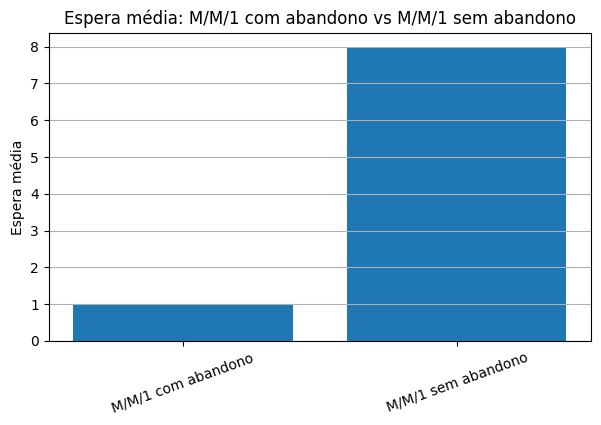

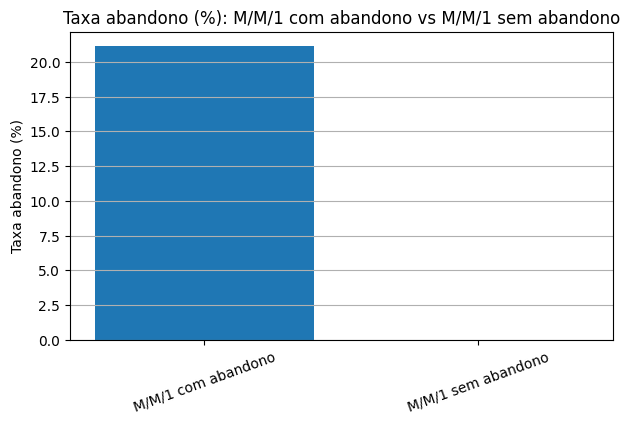

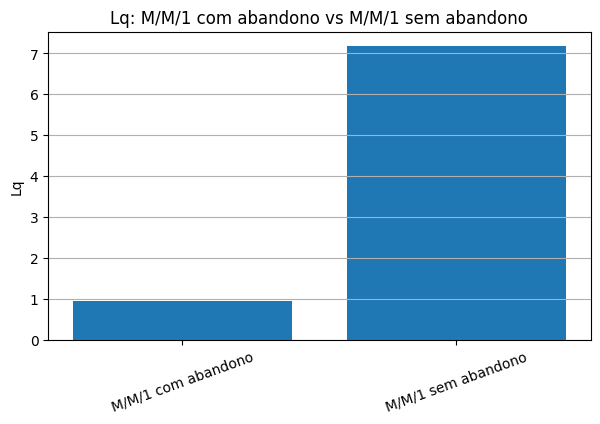

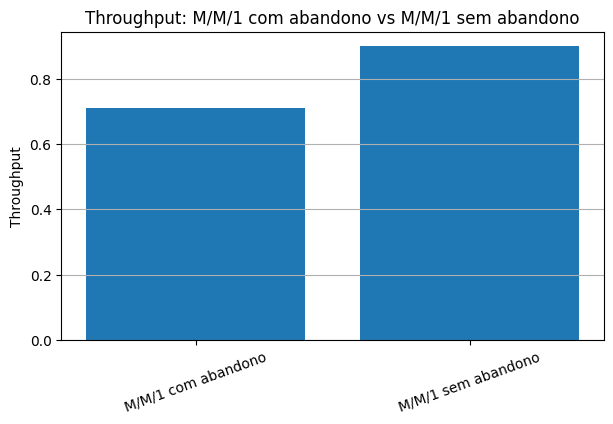

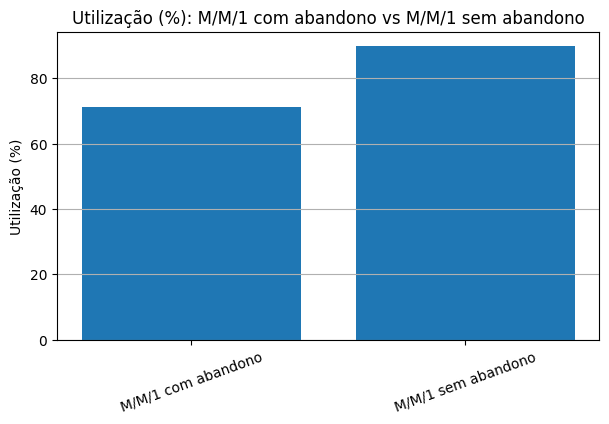

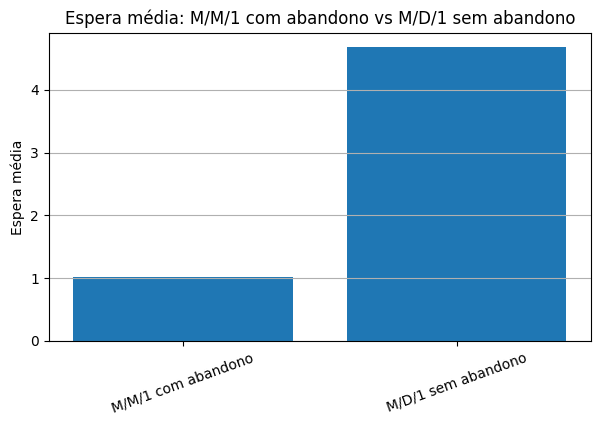

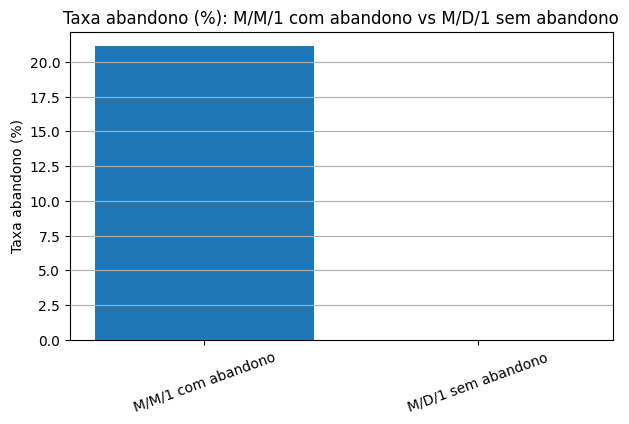

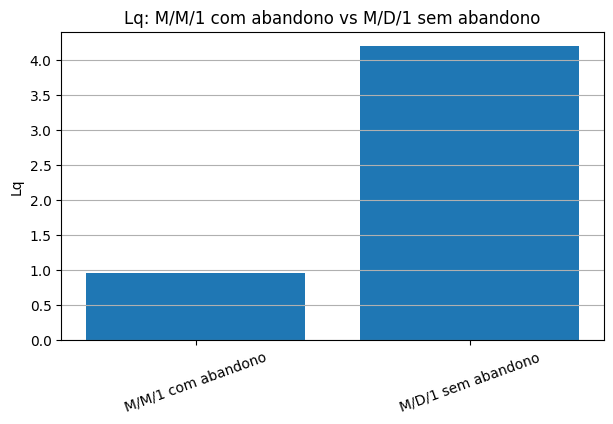

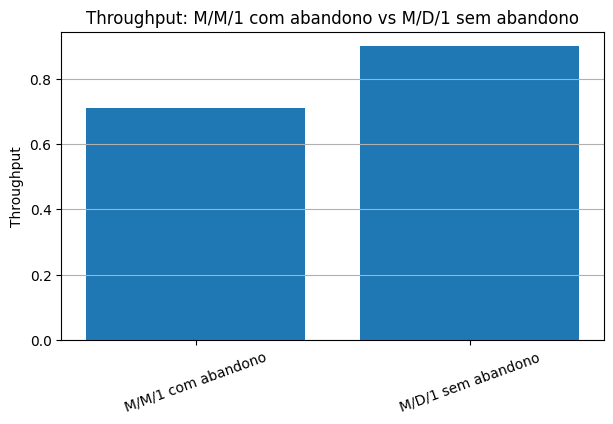

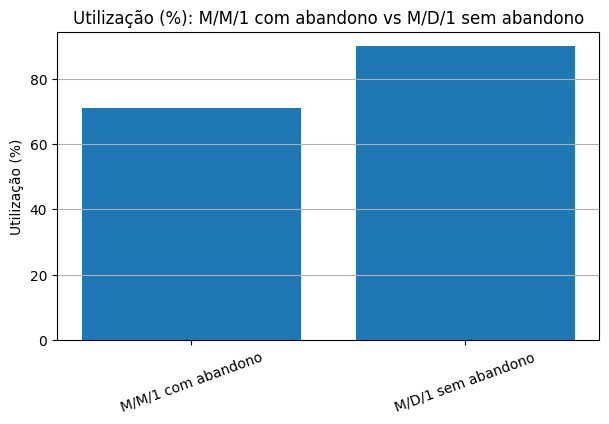

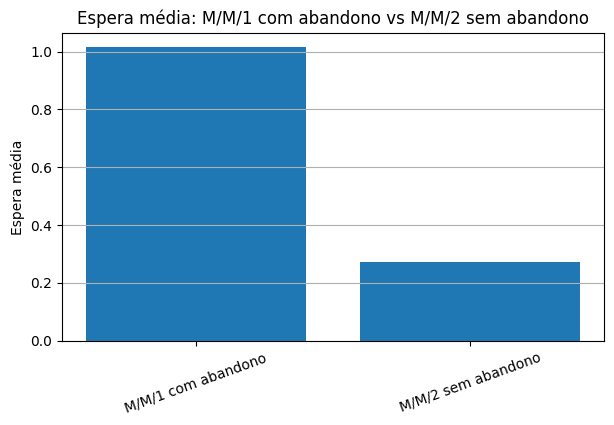

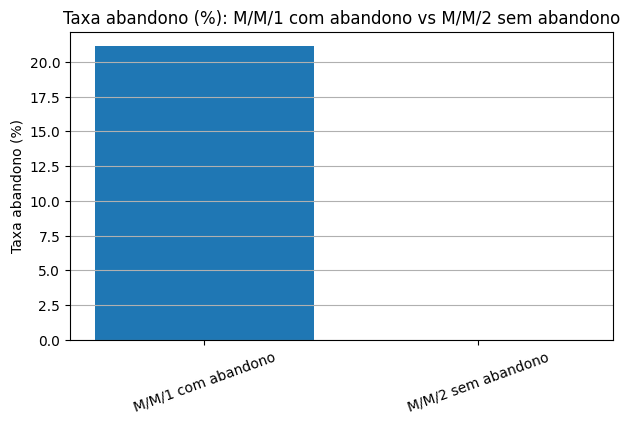

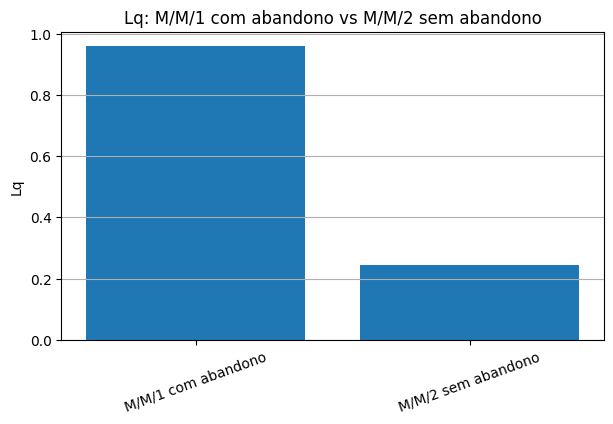

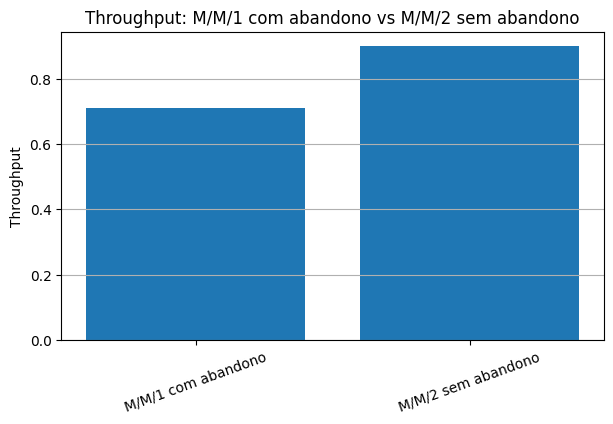

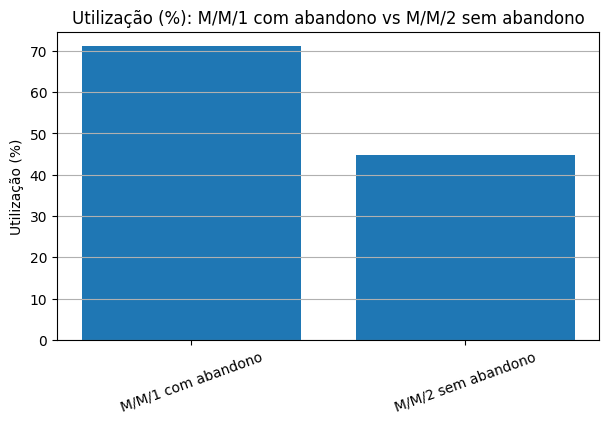

In [ ]:
# ============================================================
# CÉLULA 17 - GRÁFICOS PAR A PAR
# ============================================================

metricas_graficos = [
    "Espera média",
    "Taxa abandono (%)",
    "Lq",
    "Throughput",
    "Utilização (%)"
]

for modelo_a, modelo_b in pares:

    df_par = df_comparacoes[
        df_comparacoes["Modelo"].isin([modelo_a, modelo_b])
    ]

    for metrica in metricas_graficos:

        plt.figure(figsize=(7, 4))

        plt.bar(
            df_par["Modelo"],
            df_par[metrica]
        )

        plt.title(metrica + ": " + modelo_a + " vs " + modelo_b)
        plt.ylabel(metrica)
        plt.xticks(rotation=20)
        plt.grid(axis="y")
        plt.show()